## Sezione 1 - Caricamento ed ispezione statistica

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

df = data.frame

print(df.shape)
print(df.describe())

print(df.isnull().sum()) ## somma di tutti i valori nulli

print(df.columns.tolist())


(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  


1. `fetch_california_housing()` restituisce un oggetto di tipo Bunch,
   che è essenzialmente un dizionario con accesso ad attributi. 
   Contiene: data.data (la matrice X), data.target (il vettore y), 
   data.feature_names, data.DESCR (descrizione testuale).

   Il parametro `as_frame=True` dice a sklearn di restituire tutto come DataFrame pandas
   invece che come array numpy. Usando `data.frame`si ottiene un unico DataFrame con sia le feature che la target uniti in un'unica tabella. La colonna target si chiama `MedHouseval`.

2. `df.isnull()` restituisce un DataFrame booleano, `True` dove il valore è NaN. 
    `.sum()` somma colonna per colonna (True vale 1, False vale 0). Il risultato sarà il conteggio dei valori mancanti per feature. In questo dataset troveremo tutti zeri, il che è raro nella realtà, i missing values sono la norma e richiedono imputazione.

## Sezione 2 - Analisi della distribuzione (Richiami probabilita')

Nella sezione 1 abbiamo visto i numeri, in questa andremo a vedere la forma della distribuzione. Il ML fa assunzioni probabilistiche sui dati. Vedere la distribuzione dice subito se ci sono asimmetrie, code pesanti, valori anomali concentrati o distribuzioni bimodali che potrebbero suggerire la presenza di sottopopolazioni distinte. 

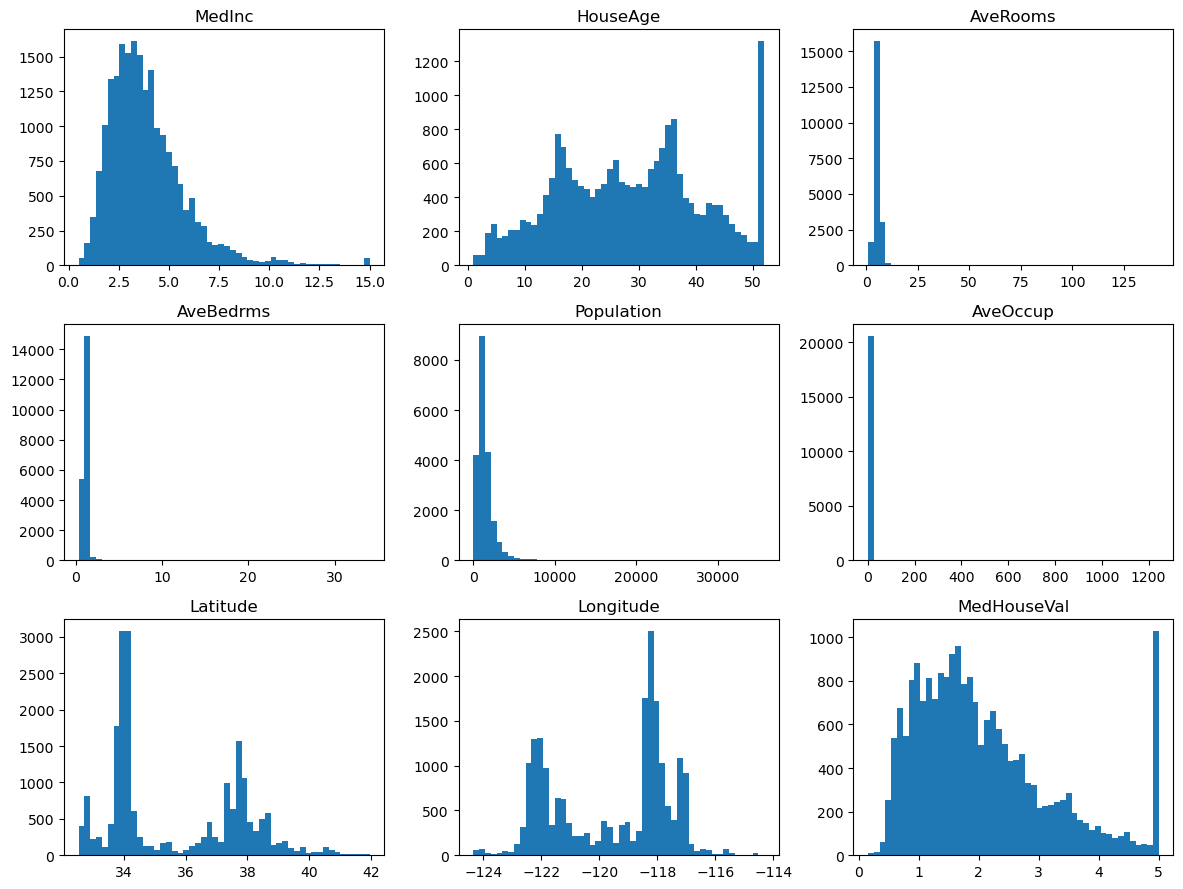

In [ ]:
import matplotlib.pyplot as plt

# Creo una griglia 3x3. fig => figura intera, axes array =>numpy
fig, axes = plt.subplots(3,3, figsize=(12,9))
# zip => accoppio ciascun pannello ad una colonna
for ax, col in zip(axes.flatten(), df.columns):
    ax.hist(df[col], bins=50)
    ax.set_title(col)
plt.tight_layout()
plt.show()

1. `axes.flatten()` trasforma l'array 2D (3x3) in un array 1D di 9 elementi. Serve perché il   `for` vuole iterare su una sequenza lineare, non su una matrice.
2. `zip(axes.flatten(), df.columns)` accoppia ogni pannello con una colonna del DataFrame. Al primo giro: primo pannello+prima colonna. Al secondo: secondo pannello+seconda colonna. e così via.
3. `ax.hist(df[col], bins=50)` disegna l'istogramma della colonna `col` nel pannello `ax`. 
    `bins=50` divide il range dei valori in 50 intervalli: più bins più dettaglio, ma su pochi dati si rischia rumore.
4. `plt.tight_layout()` aggiusta automaticamente i margini per evitare che i titoli si sovrappongano.

**Domanda critica**: la target `MedHouseVal` ha una distribuzione simmetrica o skewed? Perché questo può impattare un modello lineare? Caclola skewness e curtosi:

In [5]:
print(df['MedHouseVal'].skew())
print(df['MedHouseVal'].kurt())

0.9777632739098345
0.3278702429465876


La **skewness** misura l'asimmetria della distribuzione. Vale 0 per una gaussiana perfetta. Positiva significa coda a destra, negativa significa coda a sinistra.

La **curtosi** misura quanto sono pesanti le code rispetto a una gaussiana. Valorti alti indicano più valori estremi di quanto ci si aspetterebbe.

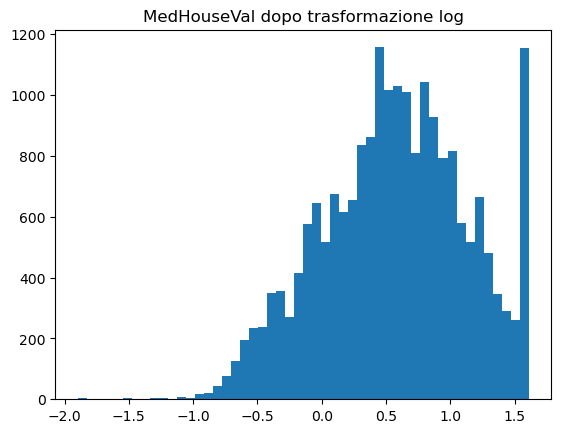

-0.17317539032496646


In [10]:
df['MedHouseVal_log'] = np.log(df['MedHouseVal'])

plt.hist(df['MedHouseVal_log'], bins=50)
plt.title('MedHouseVal dopo trasformazione log')
plt.show()

print(df['MedHouseVal_log'].skew())

df = df.drop(columns='MedHouseVal_log')

Il Logaritmo **comprime** le distanze lasciando più spazio ai valori piccoli, possiamo osservare come il valore skew scenda a `-0.173` il che significa che la nostra distribuzione è quasi simmetrica.

## Sezione 3 - Correlazione e multicollinearità
Nella sezione 2 abbiamo analizzato ogni colonna singolarmente. Ora invece guardiamo le colonne in relazione tra loro. Quando una feature cresce, un'altra tende a crescere o a scendere?


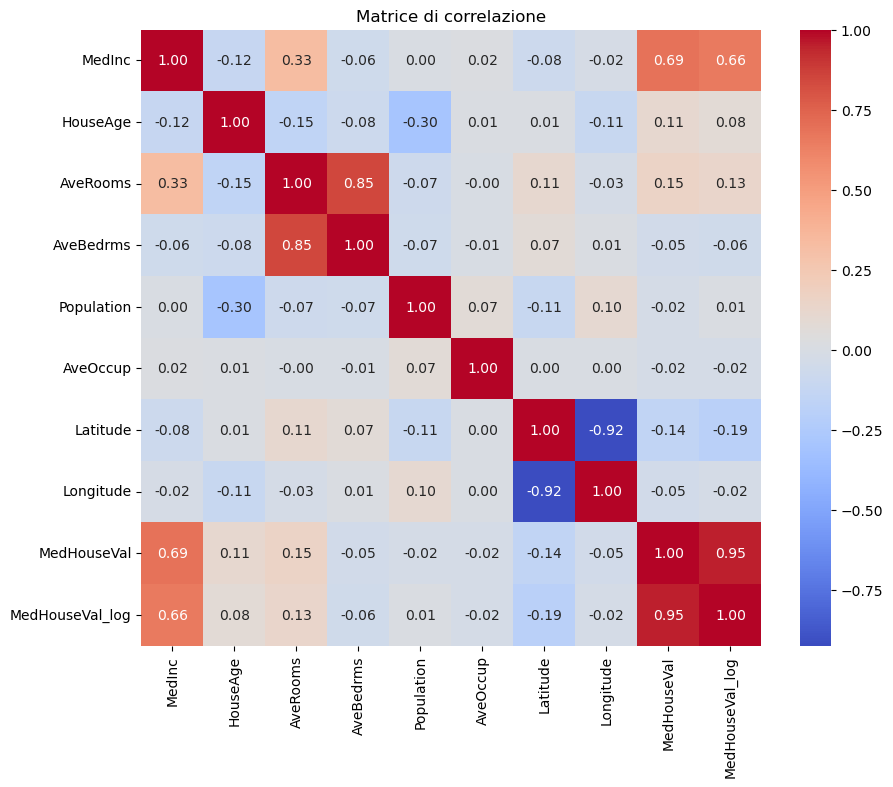

In [8]:
import seaborn as sns

corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matrice di correlazione")
plt.show()

1. `df.corr()` calcola la matrice di correlazione di Pearson tra tutte le colonne numeriche. Il risultato è una matrice quadrata dxd dove ogni cella (i,j) contiene il coefficiente di correlazione tra la colonna i e la colonna j. Il valore va sempre da -1 a +1.
2. `sns.heatmap(...)` visualizza questa matrice come una griglia colorata. `annot=True` scrive il numero dentro ogni cella. `cmap='coolwarm'` usa rosso per correlazioni positive e blu per negative.

possiamo notare come la correlazione tra le feature `AveBedrms` e `AveRooms` sia molto alta, possiamo parlare di **multicollinearità** perché i due valori in realtà vanno di pari passo e quindi non si riesce davvero a capire, nell'ottica del target, quale dei due influenzi di più. 

Cosa si fa? Si attua la **feature selection**, ovvero si rimuove una delle due feature ridondanti. Se `AveRooms` e `AveBedrms` dicono quasi la stessa cosa, teniamo la più informativa e scartiamo l'altra.

## Sezione 4 - Split train/test

In questa sezione alleniamo il modello di ML

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (16512, 8), Test: (4128, 8)


1. `df.drop(columns='MedHouseVal')` rimuove la colonna target dal DataFrame, lasciando solo le feature. `y` invece contiene solo la colonna target.
2. `test_size=0.2` significa che il 20% dei dati va nel test set e l'80% nel training set. `random_state=42` fissa il seme del generatore casuale: garantisce che ogni volta che esegui il codice ottieni la stessa divisione. Senza questo parametro ogni esecuzione darebbe una divisione diversa e i risultati non sarebbero riproducibili.

## Sezione 5 - Preprocessing della Pipeline corretta

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print(f'MSE = {mse:.4f}')
print(f'RMSE = {np.sqrt(mse):.4f}')
print(f'R2 = {r2:.4f}')


MSE = 0.5559
RMSE = 0.7456
R2 = 0.5758


1. La Pipeline prende una lista di tuple. Ogni tupla ha due elementi: un nome che diamo noi (una stringa arbitraria) e un oggetto sklearn. I passi vengono eseguiti **in ordine**: prima lo scaler e poi il modello.

2. `pipe.fit(X_train, y_train)` fa due cose in sequenza automaticamente: calcola la media e std di ogni feature **solo su X_train** e trasforma X_train, poi addestra la regressione lineare sui dati trasformati.

3. `y_pred = pipe.predict(X_test)` anche qui due cose automatiche: trasforma X_test usando media e std già calcolate sul train (mai ricalcolate), poi predice i valori.

## Sezione 6 - Visualizzazione dei residui

Il **residuo** è semplicemente la differenza tra il valore reale e quello predetto dal modello. Se il modello predice perfettamente, il residuo è 0.

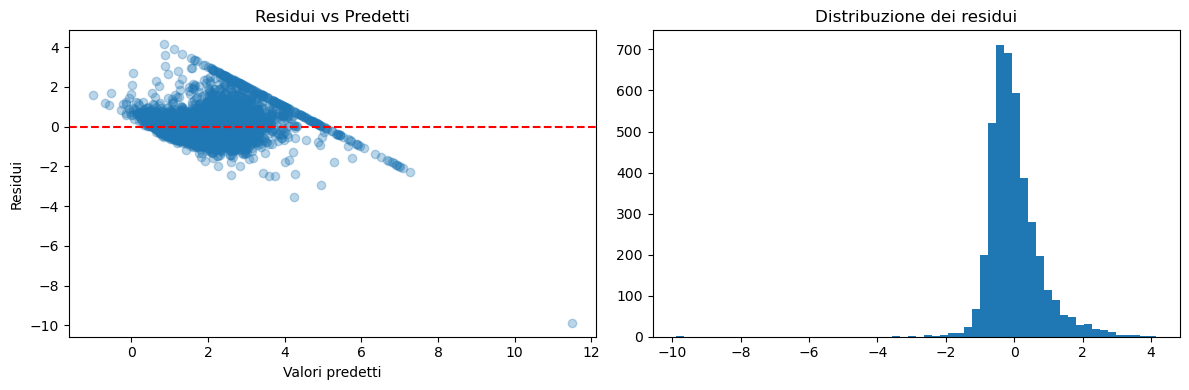

Media residui: 0.0035
Std residui:   0.7457


In [14]:
residui = y_test - y_pred

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(y_pred, residui, alpha=0.3)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Valori predetti')
ax1.set_ylabel('Residui')
ax1.set_title('Residui vs Predetti')

ax2.hist(residui, bins=60)
ax2.set_title('Distribuzione dei residui')
plt.tight_layout()
plt.show()

print(f'Media residui: {residui.mean():.4f}')
print(f'Std residui:   {residui.std():.4f}')

1. `plt.subplots(1, 2)` significa: crea una griglia di 1 riga e 2 colonne, quindi 2 pannelli affiancati. Restituisce due cose: fig che è la figura intera, e i due pannelli ax1 e ax2.

2. `ax1.scatter(y_pred, residui, alpha=0.3)` disegna uno scatter plot nel primo pannello. `aplha=0.3` rende i punti semi-trasparenti per vedere dove si sovrappongono.

3. `ax1.axhline(0, color='red', linestyle='--')` disegna una linea rossa orizzontale tratteggiata a quota 0, che rappresenta la perfezione: residuo zero significa predizione esatta.

4. `ax2.hist(residui, bins=60)` disegna l'istogramma dei residui nel secondo pannello. `bins=60` divide il range in 60 intervalli.

---

1.  Grafico 1: Residui vs Valori predetti (scatter)
    Sull'asse X ci sono i valori predetti dal modello, sull'asse Y i residui corrispondenti. La linea rossa a quota 0 rappresenta il caso ideale. Un modello senza errori sistematici mostra i punti distribuiti casualmente e simmetricamente attorno alla linea rossa, senza pattern evidenti. Se invece vedessi i punti formare una curva o un imbuto, significherebbe che il modello sbaglia in modo sistematico in certe zone di predizione.

2.  Grafico 2: Distribuzione dei residui (istogramma)
    Mostra la forma della distribuzione degli errori. Un modello lineare ben calibrato produce residui distribuiti come una gaussiana centrata sullo zero. Se la distribuzione fosse asimmetrica o multimodale, indicherebbe che il modello non sta catturando tutta la struttura dei dati.

I due grafici insieme ti danno una diagnosi completa: il primo ti dice dove sbaglia il modello, il secondo ti dice come sono distribuiti gli errori globalmente.

## Sezione 7 - Confronto stimatori con cross-validation

Nella sezione 5 abbiamo valutato il modello su un singolo split train/test. Il problema è che quel risultato dipende da come è stato fatto lo split. Se per caso nel test set sono finiti campioni particolarmente facili o difficili, il risultato è distorto.

La **cross-validation** risolve questo problema.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso

modelli = {
    'OLS' : LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'Lasso' : Lasso(alpha=0.1),
}

for nome, modello in modelli.items():
    # Itero sul dizionario e ad ogni giro creo una pipeline identica a quella della sezione 5, 
    # ma con il modello che cambia ad ogni giro
    pipe_cv = Pipeline([('Scaler', StandardScaler()), ('model', modello)])

    # Esegue la cross-validation a 5 fold, resistuisce un array di 5 valori di MSE, uno per fold
    scores = cross_val_score(pipe_cv, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
    
    mse_cv = -scores.mean()
    std_cv = scores.std()
    print(f'{nome:8s} MSE_cv = {mse_cv:.4f} ± {std_cv:.4f}')

OLS      MSE_cv = 0.5193 ± 0.0149
Ridge    MSE_cv = 0.5193 ± 0.0149
Lasso    MSE_cv = 0.6721 ± 0.0138
